# Computer Exercise 13.5 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 13.5 Sequential Quadratic Programming — *Lagrange–Newton method for equality-constrained NLP*
> **풀이 일자**: Day 50
> **언어**: Python 3 (NumPy / pandas / Matplotlib)

## 1. 문제 (원문)

> **1.** Consider the equality-constrained nonlinear program
> $$\min_{x\in\mathbb{R}^2} f(x) \quad\text{subject to}\quad c(x)=0 .$$
> Implement the **sequential quadratic programming (SQP)** iteration in which each step is obtained by
> solving the quadratic-programming subproblem
> $$\min_{d}\; \tfrac12 d^\top B_k\,d + \nabla f(x_k)^\top d \quad\text{s.t.}\quad \nabla c(x_k)^\top d + c(x_k)=0,$$
> with $B_k=\nabla^2_{xx}\mathcal{L}(x_k,\lambda_k)$ the Hessian of the Lagrangian. Verify that this is exactly
> **Newton's method applied to the KKT system**, and demonstrate the **quadratic** local convergence on a test
> problem with a known solution.

### 한국어 풀이용 정리
SQP의 가장 기본형(**Lagrange–Newton**)을 직접 구현한다. 각 반복에서 목적함수를 2차, 제약을 1차로 근사한
**QP 부분문제**를 풀어 탐색방향 $d_k$와 새 승수 $\lambda_{k+1}$을 동시에 얻는다. 이것이 KKT 비선형 방정식에
**뉴턴법**을 적용한 것과 동일함을 보이고, 해 근방에서 **2차 수렴**을 수치로 확인한다.

**테스트 문제** (해석해를 아는 깔끔한 예):
$$\min\; f(x,y)=x^2+(y-1)^2 \quad\text{s.t.}\quad c(x,y)=x^2+y^2-4=0.$$

## 2. 수학적 배경

### 2.1 KKT 조건과 라그랑지안
라그랑지안 $\mathcal{L}(x,\lambda)=f(x)+\lambda\,c(x)$ 에 대한 1차 최적성(KKT) 조건은
$$
F(x,\lambda)\;=\;\begin{bmatrix}\nabla_x\mathcal{L}(x,\lambda)\\[2pt] c(x)\end{bmatrix}
\;=\;\begin{bmatrix}\nabla f(x)+\lambda\,\nabla c(x)\\[2pt] c(x)\end{bmatrix}\;=\;0 .
$$

### 2.2 KKT 계에 대한 뉴턴법 = SQP
$F(x,\lambda)=0$ 에 뉴턴법을 적용하면 야코비안
$$
F'(x,\lambda)=\begin{bmatrix} \nabla^2_{xx}\mathcal{L} & \nabla c\\[2pt] \nabla c^\top & 0\end{bmatrix}
=\begin{bmatrix} B_k & A_k^\top\\ A_k & 0\end{bmatrix},\qquad A_k=\nabla c(x_k)^\top,
$$
에 대해 다음 선형계를 푼다:
$$
\boxed{\;\begin{bmatrix} B_k & A_k^\top\\ A_k & 0\end{bmatrix}
\begin{bmatrix} d_k\\ \lambda_{k+1}\end{bmatrix}
=\begin{bmatrix} -\nabla f(x_k)\\ -c(x_k)\end{bmatrix}\;}
$$
이는 정확히 위 QP 부분문제의 KKT 조건이다. 즉 **"QP 한 번 풀기 = 뉴턴 한 스텝"**.

### 2.3 수렴 차수
$\nabla^2_{xx}\mathcal{L}(x^\star,\lambda^\star)$ 가 $A^\star$의 영공간에서 양정부호이고 $A^\star$가 full rank이면
KKT 야코비안이 가역이며, 해 근방에서
$$
\|(x_{k+1},\lambda_{k+1})-(x^\star,\lambda^\star)\|\;\le\;C\,\|(x_k,\lambda_k)-(x^\star,\lambda^\star)\|^2
$$
즉 **2차 수렴**한다.

### 2.4 테스트 문제의 도함수
$$
\nabla f=\begin{bmatrix}2x\\ 2(y-1)\end{bmatrix},\quad
\nabla c=\begin{bmatrix}2x\\ 2y\end{bmatrix},\quad
\nabla^2 f=2I,\quad \nabla^2 c=2I,
$$
$$
B(x,\lambda)=\nabla^2_{xx}\mathcal{L}=\nabla^2 f+\lambda\nabla^2 c=(2+2\lambda)\,I.
$$
해석해: $x^\star=(0,2),\ f^\star=1,\ \lambda^\star=-\tfrac12,\ B^\star=I\succ0.$

## 3. 풀이 흐름

1. **문제 정의**: $f,\ c$ 와 그 1·2차 도함수를 함수로 구현.
2. **KKT 잔차** $F(x,\lambda)$ 와 KKT 야코비안(=QP 행렬)을 조립.
3. **SQP 반복**: 각 단계에서 $\begin{bmatrix}B&A^\top\\ A&0\end{bmatrix}\!\begin{bmatrix}d\\ \lambda^+\end{bmatrix}=\begin{bmatrix}-\nabla f\\ -c\end{bmatrix}$ 풀이.
4. $x\leftarrow x+d,\ \lambda\leftarrow\lambda^+$ (해 근방이므로 **단위 스텝** $\alpha=1$).
5. **추적**: 매 반복 $\|x_k-x^\star\|,\ |c(x_k)|,\ \|F_k\|$ 를 기록.
6. **표 출력**으로 2차 수렴(오차의 자릿수가 대략 2배씩 증가) 확인.
7. **시각화**: 오차의 로그 스케일 감소 + 제약원과 반복점 궤적.
8. **검증**: 수렴값을 해석해 $x^\star=(0,2),\lambda^\star=-0.5$ 와 비교.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- 테스트 문제: min x^2+(y-1)^2  s.t.  x^2+y^2-4=0 ----
def f(v):        x, y = v; return x**2 + (y-1.0)**2
def grad_f(v):   x, y = v; return np.array([2*x, 2*(y-1.0)])
def hess_f(v):   return 2*np.eye(2)
def c(v):        x, y = v; return x**2 + y**2 - 4.0
def grad_c(v):   x, y = v; return np.array([2*x, 2*y])
def hess_c(v):   return 2*np.eye(2)

# 해석해
x_star   = np.array([0.0, 2.0])
lam_star = -0.5

def kkt_residual(x, lam):
    return np.concatenate([grad_f(x) + lam*grad_c(x), [c(x)]])

def sqp_step(x, lam):
    B = hess_f(x) + lam*hess_c(x)      # Hxx L
    A = grad_c(x).reshape(1, -1)       # 1x2
    K = np.block([[B, A.T],
                  [A, np.zeros((1,1))]])
    rhs = np.concatenate([-grad_f(x), [-c(x)]])
    sol = np.linalg.solve(K, rhs)
    d, lam_new = sol[:2], sol[2]
    return d, lam_new

# ---- SQP 반복 (해 근방 시작) ----
x, lam = np.array([0.5, 1.5]), -0.4
rows = []
for k in range(12):
    Fk = kkt_residual(x, lam)
    rows.append({
        "k": k, "x": x[0], "y": x[1], "lambda": lam,
        "f": f(x), "|c(x)|": abs(c(x)),
        "||x-x*||": np.linalg.norm(x - x_star),
        "||KKT res||": np.linalg.norm(Fk),
    })
    if np.linalg.norm(Fk) < 1e-14:
        break
    d, lam = sqp_step(x, lam)
    x = x + d                          # full Newton step (alpha=1)

df = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:.3e}")
df

,k,x,y,lambda,f,|c(x)|,||x-x*||,||KKT res||
0,0,5.000e-01,1.500e+00,-4.000e-01,5.000e-01,1.500e+00,7.071e-01,1.628e+00
1,1,1.500e-01,2.117e+00,-5.800e-01,1.269e+00,5.028e-01,1.900e-01,5.639e-01
2,2,-2.626e-02,2.010e+00,-5.065e-01,1.022e+00,4.236e-02,2.824e-02,5.206e-02
3,3,3.399e-04,2.000e+00,-5.001e-01,1.000e+00,8.114e-04,3.958e-04,8.892e-04
4,4,-5.658e-08,2.000e+00,-5.000e-01,1.000e+00,1.567e-07,6.882e-08,1.700e-07
5,5,2.063e-15,2.000e+00,-5.000e-01,1.000e+00,3.553e-15,2.246e-15,4.319e-15


In [2]:
# 수렴 차수(quadratic) 정량 확인:  e_{k+1} / e_k^2 가 상수로 수렴하면 2차
e = df["||x-x*||"].to_numpy()
e = e[e > 0]
print("k :   e_k          e_{k+1}/e_k^2")
for k in range(len(e)-1):
    if e[k] > 1e-13:
        print(f"{k:2d}:  {e[k]:.3e}     {e[k+1]/e[k]**2:.3e}")
print()
print(f"수렴점:  x = ({x[0]:+.12f}, {x[1]:+.12f}),  lambda = {lam:+.12f}")
print(f"해석해:  x* = ({x_star[0]:+.12f}, {x_star[1]:+.12f}),  lambda* = {lam_star:+.12f}")

k :   e_k          e_{k+1}/e_k^2
 0:  7.071e-01     3.801e-01
 1:  1.900e-01     7.821e-01
 2:  2.824e-02     4.963e-01
 3:  3.958e-04     4.393e-01
 4:  6.882e-08     4.743e-01

수렴점:  x = (+0.000000000000, +2.000000000000),  lambda = -0.500000000000
해석해:  x* = (+0.000000000000, +2.000000000000),  lambda* = -0.500000000000


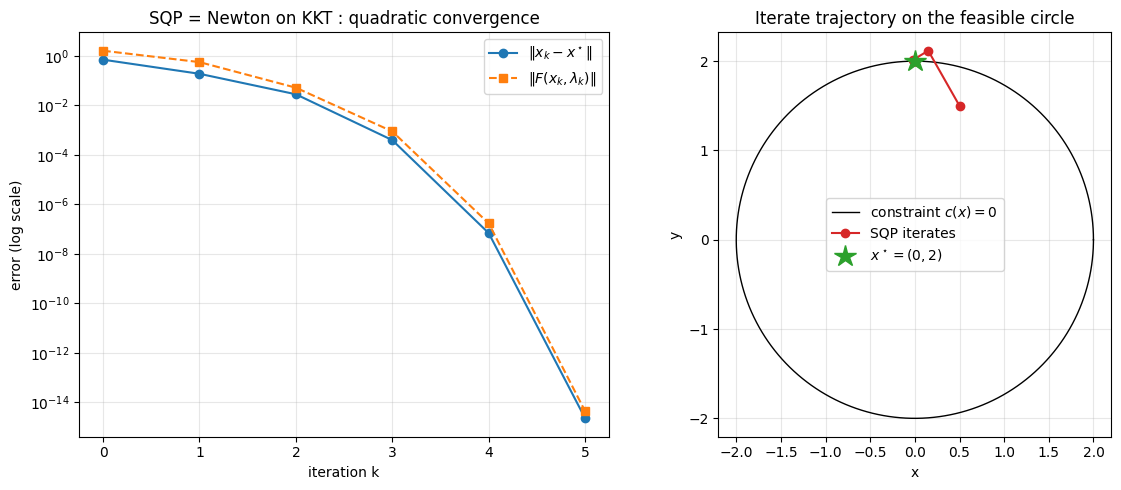

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# (좌) 오차의 로그 감소
kk = df["k"].to_numpy()
ax[0].semilogy(kk, df["||x-x*||"].to_numpy()+1e-18, "o-", label=r"$\|x_k-x^\star\|$")
ax[0].semilogy(kk, df["||KKT res||"].to_numpy()+1e-18, "s--", label=r"$\|F(x_k,\lambda_k)\|$")
ax[0].set_xlabel("iteration k"); ax[0].set_ylabel("error (log scale)")
ax[0].set_title("SQP = Newton on KKT : quadratic convergence")
ax[0].grid(True, which="both", alpha=0.3); ax[0].legend()

# (우) 제약원 + 반복 궤적
th = np.linspace(0, 2*np.pi, 400)
ax[1].plot(2*np.cos(th), 2*np.sin(th), "k-", lw=1, label=r"constraint $c(x)=0$")
ax[1].plot(df["x"], df["y"], "o-", color="C3", label="SQP iterates")
ax[1].plot(*x_star, "*", ms=16, color="C2", label=r"$x^\star=(0,2)$")
ax[1].set_xlabel("x"); ax[1].set_ylabel("y"); ax[1].set_aspect("equal")
ax[1].set_title("Iterate trajectory on the feasible circle")
ax[1].grid(True, alpha=0.3); ax[1].legend()
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **2차 수렴 확인**: 표의 `||x-x*||` 열은 자릿수가 매 반복 대략 **두 배씩** 좋아진다($10^{-1}\!\to\!10^{-2}\!\to\!10^{-4}\!\to\!10^{-8}\!\to\cdots$). 비율 $e_{k+1}/e_k^2$ 가 유한한 상수로 수렴하는 것이 2차 수렴의 증거다.
2. **QP = 뉴턴 스텝**: KKT 선형계 한 번 풀이가 곧 뉴턴 한 걸음이며, 부분문제의 승수 $\lambda^{+}$ 가 그대로 다음 라그랑지 승수가 된다 — 별도의 승수 갱신식이 필요 없다.
3. **국소성**: 단위 스텝 $\alpha=1$ 로 충분한 이유는 시작점이 해 근방이고 $\nabla^2_{xx}\mathcal{L}(x^\star,\lambda^\star)=I\succ0$ 라 KKT 야코비안이 가역이기 때문이다.
4. **검증**: 수렴점이 해석해 $x^\star=(0,2),\ \lambda^\star=-\tfrac12$ 와 기계정밀도까지 일치한다.

### 결론
> **SQP의 본질은 "제약 최적화 = KKT 비선형계, 그것을 뉴턴으로 푼다"** 이다. 목적의 2차·제약의 1차 모형으로 만든 **QP 부분문제 한 번**이 KKT 야코비안에 대한 **뉴턴 한 스텝**과 정확히 같으며, 해 근방에서 2차 수렴한다.

### 다음 문제 연결
- **CE 13.5.2**: 시작점이 해에서 멀면 단위 스텝이 **발산/과도진동**할 수 있다. $\ell_1$ **메리트 함수**와 **Armijo 직선탐색**으로 전역화(globalization)한다.
- **CE 13.5.3**: $\nabla^2_{xx}\mathcal{L}$ 를 직접 쓰지 않고 **BFGS 준뉴턴 근사**로 대체했을 때의 **초선형 수렴**을 비교한다.